✅ Tüm kütüphaneler başarıyla yüklendi!

📋 Kaggle - Water Quality Veri Seti Bilgileri
Özellik sayısı  : 9
Örnek sayısı    : 3276
Sınıf dağılımı:
  0 = İçilemez (Güvenli Değil) : 1998
  1 = İçilebilir (Güvenli)    : 1278

✅ Veri bölündü: Eğitim=2620, Test=656
✅ StandardScaler uygulandı (KNN için zorunlu, NB için gerekmez)

🎯 En iyi K değeri: 28 (Test Accuracy: 0.6555)


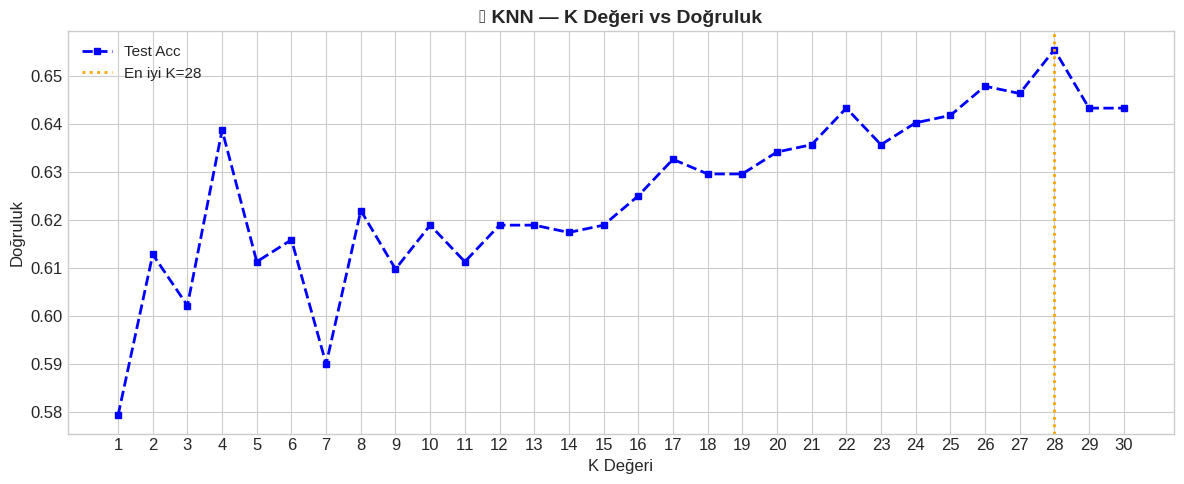


🔵 KNN MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi   : 0.008053 sn
✅ Tahmin Süresi   : 0.0424 sn
📊 Doğruluk (Acc)  : 0.6555  (65.55%)
📊 AUC-ROC         : 0.6186
📊 F1 Skoru        : 0.2893
📊 Precision       : 0.7419
📊 Recall          : 0.1797

📋 Detaylı Rapor:
              precision    recall  f1-score   support

    İçilemez       0.65      0.96      0.77       400
  İçilebilir       0.74      0.18      0.29       256

    accuracy                           0.66       656
   macro avg       0.69      0.57      0.53       656
weighted avg       0.68      0.66      0.58       656



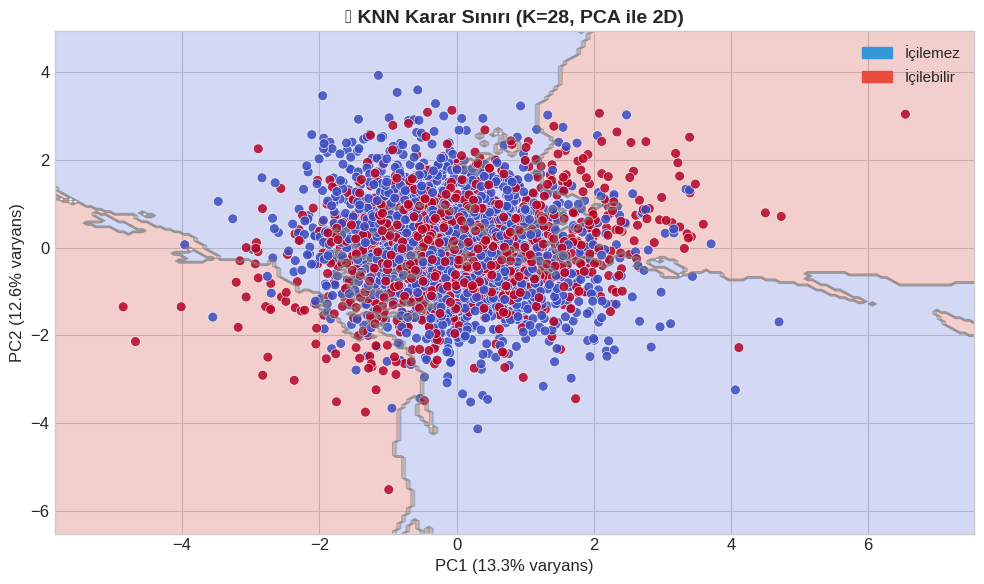


🟠 NAIVE BAYES (Gaussian) MODELİ EĞİTİLİYOR...
✅ Eğitim Süresi   : 0.003900 sn
✅ Tahmin Süresi   : 0.001945 sn
📊 Doğruluk (Acc)  : 0.6113  (61.13%)
📊 AUC-ROC         : 0.6080
📊 F1 Skoru        : 0.2693
📊 Precision       : 0.5054
📊 Recall          : 0.1836

📋 Detaylı Rapor:
              precision    recall  f1-score   support

    İçilemez       0.63      0.89      0.74       400
  İçilebilir       0.51      0.18      0.27       256

    accuracy                           0.61       656
   macro avg       0.57      0.53      0.50       656
weighted avg       0.58      0.61      0.55       656



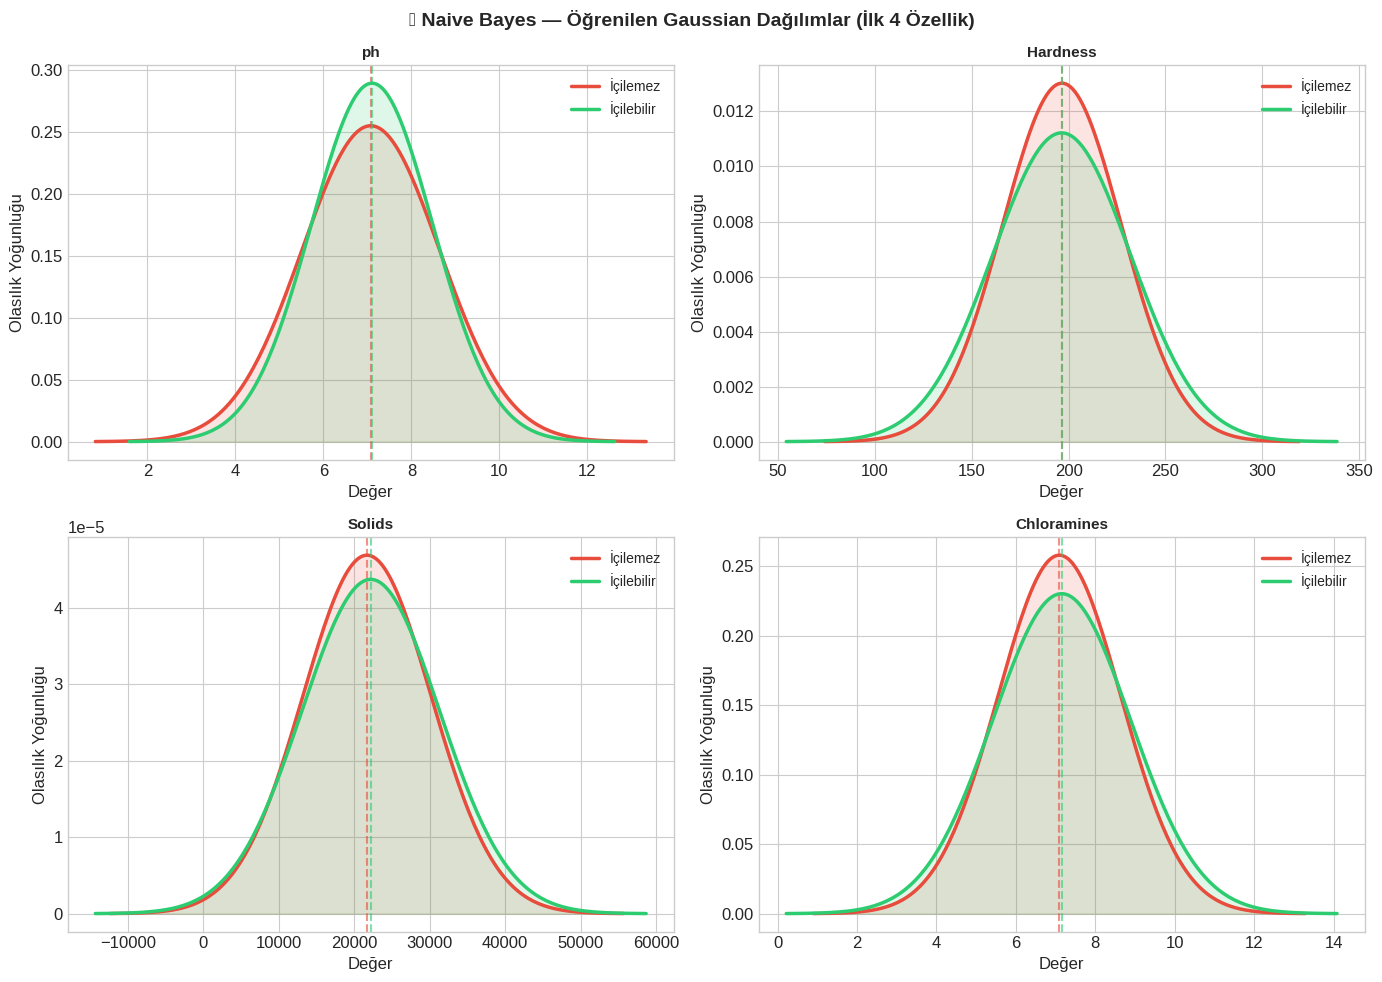

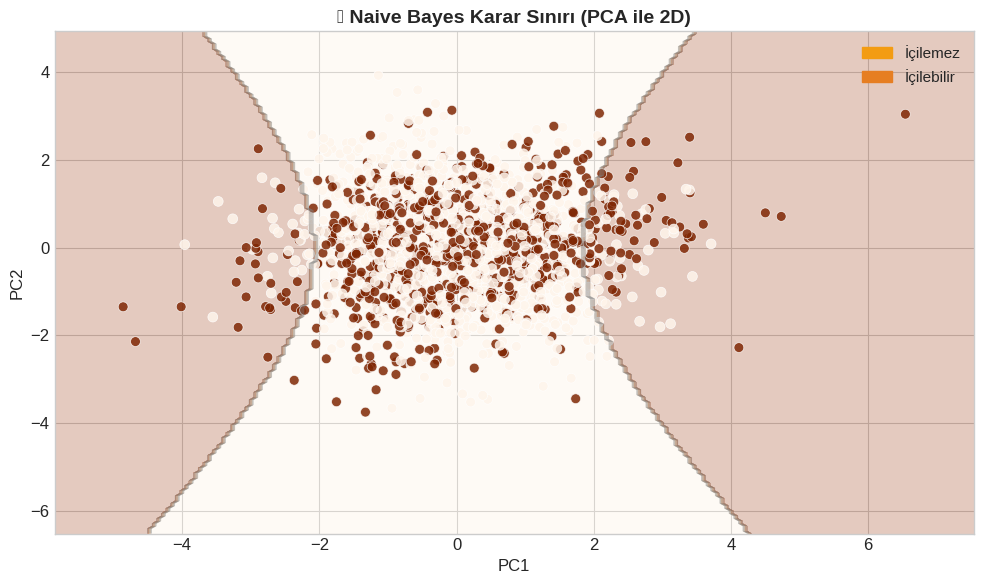

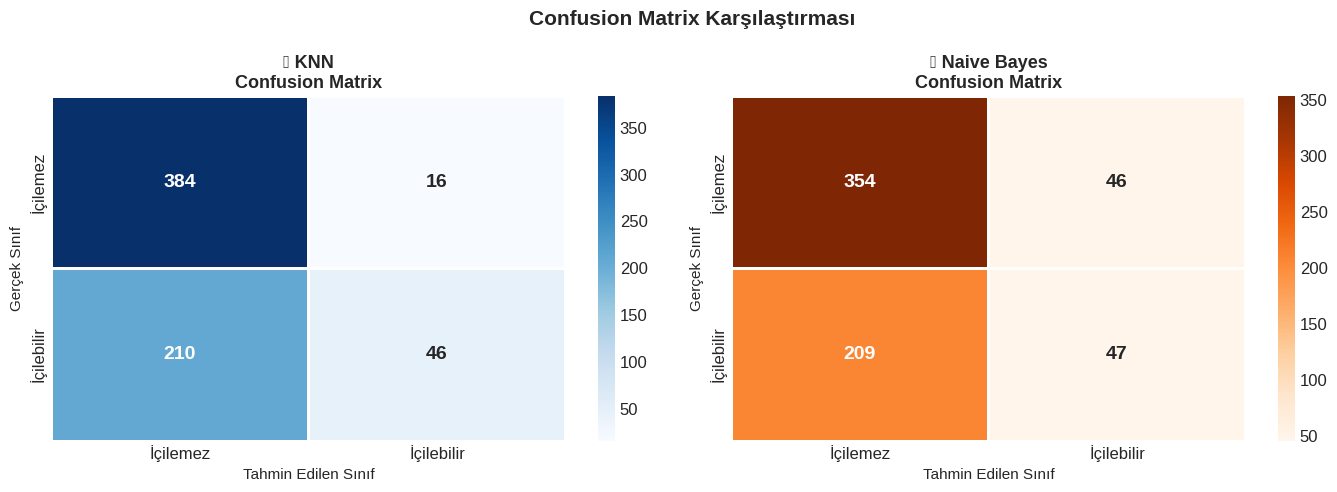

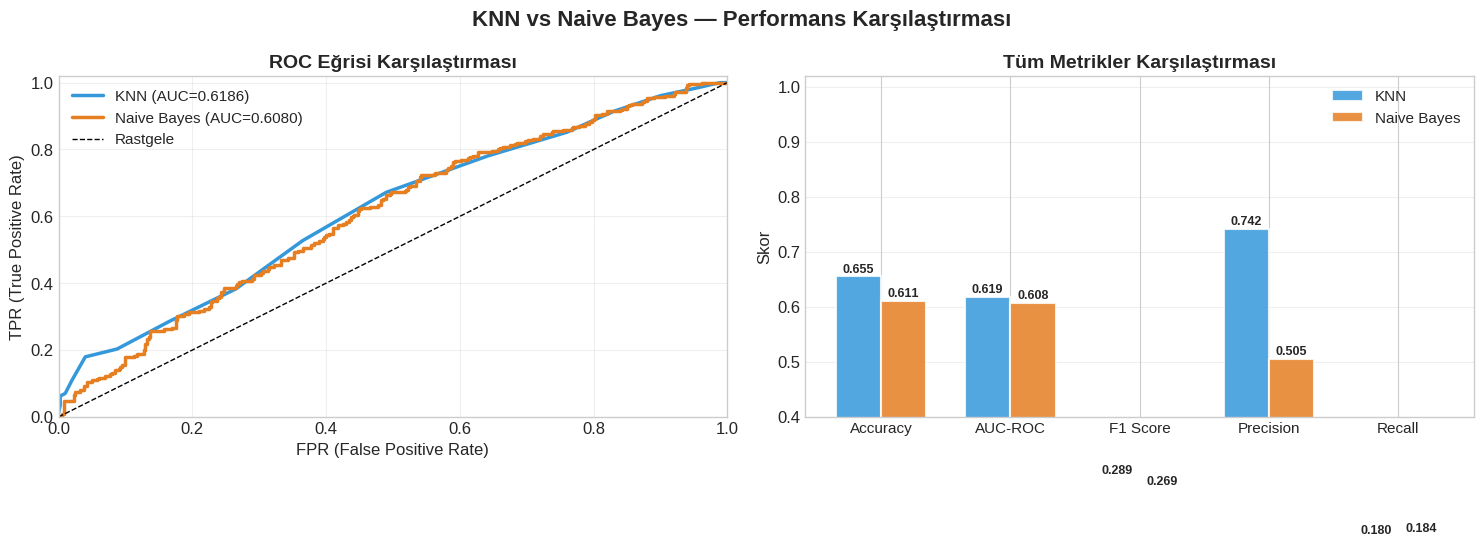


🔄 5-Fold Cross Validation...
🔵 KNN          CV: [0.622  0.6351 0.6519 0.6061 0.6458] → Ort: 0.6322 ± 0.0165
🟠 Naive Bayes  CV: [0.6082 0.6519 0.5817 0.5893 0.626 ]  → Ort: 0.6114 ± 0.0254


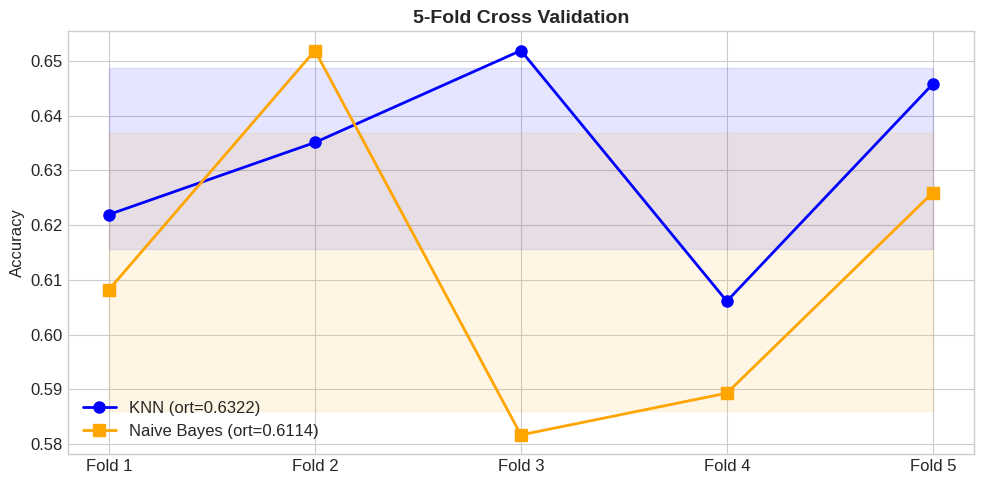

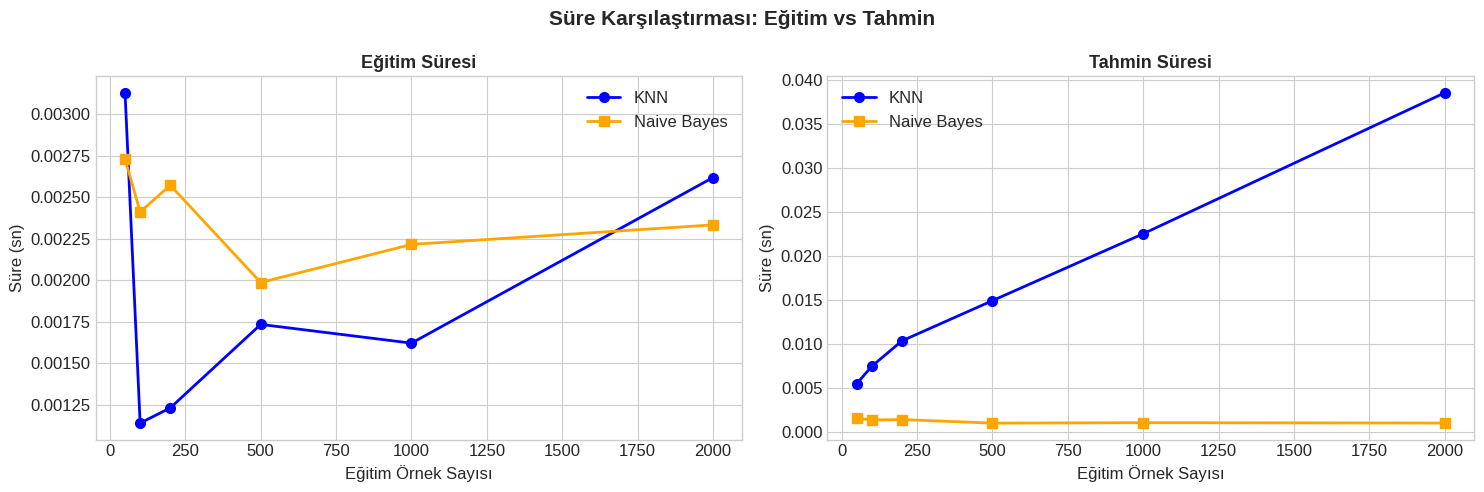


           📊 KNN vs NAIVE BAYES — SONUÇ TABLOSU
            Metrik    KNN 🔵 Naive Bayes 🟠       Kazanan
          Accuracy   0.6555        0.6113         🔵 KNN
           AUC-ROC   0.6186        0.6080         🔵 KNN
          F1 Score   0.2893        0.2693         🔵 KNN
         Precision   0.7419        0.5054         🔵 KNN
            Recall   0.1797        0.1836 🟠 Naive Bayes
       CV Ortalama   0.6322        0.6114         🔵 KNN
            CV Std   0.0165        0.0254         🔵 KNN
Eğitim Süresi (sn) 0.002618      0.002333          🟠 NB
Tahmin Süresi (sn)   0.0385      0.001073 🟠 Naive Bayes

🏆 GENEL SONUÇ:
   🔵 KNN kazandı         : 6/9 kategoride
   🟠 Naive Bayes kazandı : 2/9 kategoride


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Tüm kütüphaneler başarıyla yüklendi!')

def load_and_prepare_data(file_path='water_potability.csv', test_size=0.2, random_state=42):
    """Veri setini yükler, eksik değerleri doldurur ve eğitim/test setlerini oluşturur."""
    df = pd.read_csv(file_path)
    df.fillna(df.mean(), inplace=True)

    X = df.drop(columns=['Potability'])
    y = df['Potability']

    print('\n📋 Kaggle - Water Quality Veri Seti Bilgileri')
    print('='*50)
    print(f'Özellik sayısı  : {X.shape[1]}')
    print(f'Örnek sayısı    : {X.shape[0]}')
    print(f'Sınıf dağılımı:')
    print(f'  0 = İçilemez (Güvenli Değil) : {sum(y==0)}')
    print(f'  1 = İçilebilir (Güvenli)    : {sum(y==1)}')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    X_scaled       = scaler.fit_transform(X)

    print(f'\n✅ Veri bölündü: Eğitim={X_train.shape[0]}, Test={X_test.shape[0]}')
    print('✅ StandardScaler uygulandı (KNN için zorunlu, NB için gerekmez)')
    return X, y, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, X_scaled

def train_and_evaluate_knn(X, y, X_train_scaled, X_test_scaled, y_train, y_test, X_scaled, random_state=42):
    """KNN modelini eğitir, en iyi K değerini bulur ve performansını değerlendirir."""
    k_range = range(1, 31)
    k_test_acc  = []

    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_train_scaled, y_train)
        k_test_acc.append(accuracy_score(y_test,  knn.predict(X_test_scaled)))

    best_k = k_range[np.argmax(k_test_acc)]
    print(f'\n🎯 En iyi K değeri: {best_k} (Test Accuracy: {max(k_test_acc):.4f})')

    plt.figure(figsize=(12, 5))
    plt.plot(k_range, k_test_acc,  'b--s', markersize=5, linewidth=2, label='Test Acc')
    plt.axvline(x=best_k, color='orange', linestyle=':', linewidth=2, label=f'En iyi K={best_k}')
    plt.xlabel('K Değeri', fontsize=12)
    plt.ylabel('Doğruluk', fontsize=12)
    plt.title('🔵 KNN — K Değeri vs Doğruluk', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.xticks(k_range)
    plt.tight_layout()
    plt.show()

    print('\n🔵 KNN MODELİ EĞİTİLİYOR...')
    print('='*45)

    knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='uniform', algorithm='auto')

    start = time.time()
    knn_model.fit(X_train_scaled, y_train)
    knn_train_time = time.time() - start

    start = time.time()
    knn_pred = knn_model.predict(X_test_scaled)
    knn_pred_time = time.time() - start
    knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

    knn_acc    = accuracy_score(y_test, knn_pred)
    knn_auc    = roc_auc_score(y_test, knn_prob)
    knn_f1     = f1_score(y_test, knn_pred)
    knn_prec   = precision_score(y_test, knn_pred)
    knn_recall = recall_score(y_test, knn_pred)

    print(f'✅ Eğitim Süresi   : {knn_train_time:.6f} sn')
    print(f'✅ Tahmin Süresi   : {knn_pred_time:.4f} sn')
    print(f'📊 Doğruluk (Acc)  : {knn_acc:.4f}  ({knn_acc*100:.2f}%)')
    print(f'📊 AUC-ROC         : {knn_auc:.4f}')
    print(f'📊 F1 Skoru        : {knn_f1:.4f}')
    print(f'📊 Precision       : {knn_prec:.4f}')
    print(f'📊 Recall          : {knn_recall:.4f}\n')
    print('📋 Detaylı Rapor:')
    print(classification_report(y_test, knn_pred, target_names=['İçilemez', 'İçilebilir']))

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    X_tr_pca, X_te_pca, y_tr_pca, y_te_pca = train_test_split(X_pca, y, test_size=0.2, random_state=random_state, stratify=y)
    knn_2d = KNeighborsClassifier(n_neighbors=best_k)
    knn_2d.fit(X_tr_pca, y_tr_pca)

    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.contour(xx, yy, Z, colors='gray', linewidths=0.5, alpha=0.5)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolors='white', linewidth=0.5, s=50, alpha=0.85)

    handles = [mpatches.Patch(color='#3498db', label='İçilemez'), mpatches.Patch(color='#e74c3c', label='İçilebilir')]
    plt.legend(handles=handles, fontsize=11)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varyans)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varyans)')
    plt.title(f'🔵 KNN Karar Sınırı (K={best_k}, PCA ile 2D)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return knn_model, knn_pred, knn_prob, knn_acc, knn_auc, knn_f1, knn_prec, knn_recall, best_k, X_tr_pca, y_tr_pca, xx, yy, X_pca, knn_train_time, knn_pred_time

def train_and_evaluate_naive_bayes(X_train, X_test, y_train, y_test, X_tr_pca, y_tr_pca, X, xx, yy):
    """Naive Bayes modelini eğitir ve performansını değerlendirir."""
    print('\n🟠 NAIVE BAYES (Gaussian) MODELİ EĞİTİLİYOR...')
    print('='*50)

    nb_model = GaussianNB(var_smoothing=1e-9)

    start = time.time()
    nb_model.fit(X_train, y_train)
    nb_train_time = time.time() - start

    start = time.time()
    nb_pred = nb_model.predict(X_test)
    nb_pred_time = time.time() - start
    nb_prob = nb_model.predict_proba(X_test)[:, 1]

    nb_acc    = accuracy_score(y_test, nb_pred)
    nb_auc    = roc_auc_score(y_test, nb_prob)
    nb_f1     = f1_score(y_test, nb_pred)
    nb_prec   = precision_score(y_test, nb_pred)
    nb_recall = recall_score(y_test, nb_pred)

    print(f'✅ Eğitim Süresi   : {nb_train_time:.6f} sn')
    print(f'✅ Tahmin Süresi   : {nb_pred_time:.6f} sn')
    print(f'📊 Doğruluk (Acc)  : {nb_acc:.4f}  ({nb_acc*100:.2f}%)')
    print(f'📊 AUC-ROC         : {nb_auc:.4f}')
    print(f'📊 F1 Skoru        : {nb_f1:.4f}')
    print(f'📊 Precision       : {nb_prec:.4f}')
    print(f'📊 Recall          : {nb_recall:.4f}\n')
    print('📋 Detaylı Rapor:')
    print(classification_report(y_test, nb_pred, target_names=['İçilemez', 'İçilebilir']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    colors = ['#e74c3c', '#2ecc71']
    class_labels = ['İçilemez', 'İçilebilir']

    for i in range(4):
        feat = X.columns[i]
        for c in range(2):
            mu    = nb_model.theta_[c, i]
            sigma = np.sqrt(nb_model.var_[c, i])
            x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
            pdf = (1 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_range - mu) / sigma)**2)

            axes[i].plot(x_range, pdf, color=colors[c], linewidth=2.5, label=class_labels[c])
            axes[i].fill_between(x_range, pdf, alpha=0.15, color=colors[c])
            axes[i].axvline(mu, color=colors[c], linestyle='--', alpha=0.6, linewidth=1.5)

        axes[i].set_title(f'{feat}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Değer')
        axes[i].set_ylabel('Olasılık Yoğunluğu')
        axes[i].legend(fontsize=10)

    plt.suptitle('🟠 Naive Bayes — Öğrenilen Gaussian Dağılımlar (İlk 4 Özellik)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    nb_2d = GaussianNB()
    nb_2d.fit(X_tr_pca, y_tr_pca)
    Z_nb = nb_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z_nb, alpha=0.25, cmap='Oranges')
    plt.contour(xx, yy, Z_nb, colors='gray', linewidths=0.5, alpha=0.5)
    plt.scatter(X_tr_pca[:, 0], X_tr_pca[:, 1], c=y_tr_pca, cmap='Oranges', edgecolors='white', linewidth=0.5, s=50, alpha=0.85)

    handles = [mpatches.Patch(color='#f39c12', label='İçilemez'), mpatches.Patch(color='#e67e22', label='İçilebilir')]
    plt.legend(handles=handles, fontsize=11)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('🟠 Naive Bayes Karar Sınırı (PCA ile 2D)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return nb_model, nb_pred, nb_prob, nb_acc, nb_auc, nb_f1, nb_prec, nb_recall, nb_train_time, nb_pred_time

def comprehensive_comparison(knn_pred, nb_pred, y_test, knn_prob, nb_prob, knn_auc, nb_auc, knn_acc, nb_acc, knn_f1, nb_f1, knn_prec, nb_prec, knn_recall, nb_recall):
    """KNN ve Naive Bayes modellerinin performansını kapsamlı bir şekilde karşılaştırır."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, pred, title, color in zip(
        axes, [knn_pred, nb_pred], ['🔵 KNN', '🟠 Naive Bayes'], ['Blues', 'Oranges']
    ):
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(
            cm, annot=True, fmt='d', cmap=color, ax=ax,
            xticklabels=['İçilemez', 'İçilebilir'], yticklabels=['İçilemez', 'İçilebilir'],
            linewidths=2, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'}
        )
        ax.set_title(f'{title}\nConfusion Matrix', fontsize=13, fontweight='bold')
        ax.set_ylabel('Gerçek Sınıf', fontsize=11)
        ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=11)

    plt.suptitle('Confusion Matrix Karşılaştırması', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for prob, label, color, auc_score in [(knn_prob, 'KNN', '#3498db', knn_auc), (nb_prob, 'Naive Bayes', '#e67e22', nb_auc)]:
        fpr, tpr, _ = roc_curve(y_test, prob)
        axes[0].plot(fpr, tpr, color=color, linewidth=2.5, label=f'{label} (AUC={auc_score:.4f})')

    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele')
    axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
    axes[0].set_xlabel('FPR (False Positive Rate)', fontsize=12)
    axes[0].set_ylabel('TPR (True Positive Rate)',  fontsize=12)
    axes[0].set_title('ROC Eğrisi Karşılaştırması', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    metrics    = ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall']
    knn_scores = [knn_acc, knn_auc, knn_f1, knn_prec, knn_recall]
    nb_scores  = [nb_acc,  nb_auc,  nb_f1,  nb_prec,  nb_recall]

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = axes[1].bar(x - width/2, knn_scores, width, label='KNN', color='#3498db', alpha=0.85, edgecolor='white', linewidth=1.5)
    bars2 = axes[1].bar(x + width/2, nb_scores, width, label='Naive Bayes', color='#e67e22', alpha=0.85, edgecolor='white', linewidth=1.5)

    for bar in list(bars1) + list(bars2):
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metrics, fontsize=11)
    axes[1].set_ylabel('Skor', fontsize=12)
    axes[1].set_title('Tüm Metrikler Karşılaştırması', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].set_ylim(0.40, 1.02)
    axes[1].grid(True, axis='y', alpha=0.3)

    plt.suptitle('KNN vs Naive Bayes — Performans Karşılaştırması', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def run_cross_validation(X, y, best_k, nb_model):
    """Modeller üzerinde çapraz doğrulama yapar ve sonuçları görselleştirir."""
    print('\n🔄 5-Fold Cross Validation...')
    print('='*45)

    knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=best_k))])
    knn_cv = cross_val_score(knn_pipe, X, y, cv=5, scoring='accuracy')
    nb_cv  = cross_val_score(nb_model, X, y, cv=5, scoring='accuracy')

    print(f'🔵 KNN          CV: {knn_cv.round(4)} → Ort: {knn_cv.mean():.4f} ± {knn_cv.std():.4f}')
    print(f'🟠 Naive Bayes  CV: {nb_cv.round(4)}  → Ort: {nb_cv.mean():.4f} ± {nb_cv.std():.4f}')

    fig, ax = plt.subplots(figsize=(10, 5))
    x_fold = np.arange(5)

    ax.plot(x_fold, knn_cv, 'b-o', markersize=8, linewidth=2, label=f'KNN (ort={knn_cv.mean():.4f})')
    ax.plot(x_fold, nb_cv, '-s', color='orange', markersize=8, linewidth=2, label=f'Naive Bayes (ort={nb_cv.mean():.4f})')

    ax.fill_between(x_fold, knn_cv.mean() - knn_cv.std(), knn_cv.mean() + knn_cv.std(), alpha=0.1, color='blue')
    ax.fill_between(x_fold, nb_cv.mean() - nb_cv.std(), nb_cv.mean() + nb_cv.std(), alpha=0.1, color='orange')

    ax.set_xticks(x_fold)
    ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('5-Fold Cross Validation', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.show()
    return knn_cv, nb_cv

def plot_time_performance(X_train_scaled, X_train, y_train, X_test_scaled, X_test, best_k):
    """Veri boyutuna göre eğitim ve tahmin sürelerini karşılaştırır."""
    sizes = [50, 100, 200, 500, 1000, 2000]
    knn_train_times, nb_train_times = [], []
    knn_pred_times,  nb_pred_times  = [], []

    for s in sizes:
        Xs    = X_train_scaled[:s]
        Xs_nb = X_train.iloc[:s]
        ys    = y_train.iloc[:s]

        m_knn = KNeighborsClassifier(n_neighbors=best_k)
        t = time.time()
        m_knn.fit(Xs, ys)
        knn_train_times.append(time.time() - t)

        t = time.time()
        m_knn.predict(X_test_scaled)
        knn_pred_times.append(time.time() - t)

        m_nb = GaussianNB()
        t = time.time()
        m_nb.fit(Xs_nb, ys)
        nb_train_times.append(time.time() - t)

        t = time.time()
        m_nb.predict(X_test)
        nb_pred_times.append(time.time() - t)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(sizes, knn_train_times, 'b-o', markersize=7, linewidth=2, label='KNN')
    axes[0].plot(sizes, nb_train_times,  '-s', color='orange', markersize=7, linewidth=2, label='Naive Bayes')
    axes[0].set_title('Eğitim Süresi', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Eğitim Örnek Sayısı')
    axes[0].set_ylabel('Süre (sn)')
    axes[0].legend()

    axes[1].plot(sizes, knn_pred_times, 'b-o', markersize=7, linewidth=2, label='KNN')
    axes[1].plot(sizes, nb_pred_times,  '-s', color='orange', markersize=7, linewidth=2, label='Naive Bayes')
    axes[1].set_title('Tahmin Süresi', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Eğitim Örnek Sayısı')
    axes[1].set_ylabel('Süre (sn)')
    axes[1].legend()

    plt.suptitle('Süre Karşılaştırması: Eğitim vs Tahmin', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return knn_train_times[-1], knn_pred_times[-1], nb_train_times[-1], nb_pred_times[-1]

def display_final_results(knn_acc, knn_auc, knn_f1, knn_prec, knn_recall, knn_cv, nb_acc, nb_auc, nb_f1, nb_prec, nb_recall, nb_cv, knn_train_time, knn_pred_time, nb_train_time, nb_pred_time):
    """Modellerin nihai sonuçlarını bir tablo halinde görüntüler."""
    results_df = pd.DataFrame({
        'Metrik': ['Accuracy', 'AUC-ROC', 'F1 Score', 'Precision', 'Recall',
                   'CV Ortalama', 'CV Std', 'Eğitim Süresi (sn)', 'Tahmin Süresi (sn)']
    })

    results_df['KNN 🔵'] = [
        f'{knn_acc:.4f}',        f'{knn_auc:.4f}',
        f'{knn_f1:.4f}',         f'{knn_prec:.4f}',
        f'{knn_recall:.4f}',     f'{knn_cv.mean():.4f}',
        f'{knn_cv.std():.4f}',   f'{knn_train_time:.6f}',
        f'{knn_pred_time:.4f}'
    ]

    results_df['Naive Bayes 🟠'] = [
        f'{nb_acc:.4f}',         f'{nb_auc:.4f}',
        f'{nb_f1:.4f}',          f'{nb_prec:.4f}',
        f'{nb_recall:.4f}',      f'{nb_cv.mean():.4f}',
        f'{nb_cv.std():.4f}',    f'{nb_train_time:.6f}',
        f'{nb_pred_time:.6f}'
    ]

    results_df['Kazanan'] = [
        '🔵 KNN' if knn_acc    >= nb_acc    else '🟠 Naive Bayes',
        '🔵 KNN' if knn_auc    >= nb_auc    else '🟠 Naive Bayes',
        '🔵 KNN' if knn_f1     >= nb_f1     else '🟠 Naive Bayes',
        '🔵 KNN' if knn_prec   >= nb_prec   else '🟠 Naive Bayes',
        '🔵 KNN' if knn_recall >= nb_recall else '🟠 Naive Bayes',
        '🔵 KNN' if knn_cv.mean() >= nb_cv.mean() else '🟠 Naive Bayes',
        '🔵 KNN' if knn_cv.std()  <= nb_cv.std()  else '🟠 Naive Bayes',
        '🟠 NB',
        '🟠 Naive Bayes'
    ]

    print('\n' + '='*70)
    print('           📊 KNN vs NAIVE BAYES — SONUÇ TABLOSU')
    print('='*70)
    print(results_df.to_string(index=False))
    print('='*70)

    knn_wins = sum(1 for k in results_df['Kazanan'] if 'KNN' in k)
    nb_wins  = sum(1 for k in results_df['Kazanan'] if 'Bayes' in k)
    print(f'\n🏆 GENEL SONUÇ:')
    print(f'   🔵 KNN kazandı         : {knn_wins}/{len(results_df)} kategoride')
    print(f'   🟠 Naive Bayes kazandı : {nb_wins}/{len(results_df)} kategoride')

if __name__ == "__main__":
    X, y, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled, X_scaled = load_and_prepare_data()

    knn_model, knn_pred, knn_prob, knn_acc, knn_auc, knn_f1, knn_prec, knn_recall, best_k, X_tr_pca, y_tr_pca, xx, yy, X_pca, knn_train_time, knn_pred_time = \
        train_and_evaluate_knn(X, y, X_train_scaled, X_test_scaled, y_train, y_test, X_scaled)

    nb_model, nb_pred, nb_prob, nb_acc, nb_auc, nb_f1, nb_prec, nb_recall, nb_train_time, nb_pred_time = \
        train_and_evaluate_naive_bayes(X_train, X_test, y_train, y_test, X_tr_pca, y_tr_pca, X, xx, yy)

    comprehensive_comparison(knn_pred, nb_pred, y_test, knn_prob, nb_prob, knn_auc, nb_auc, knn_acc, nb_acc, knn_f1, nb_f1, knn_prec, nb_prec, knn_recall, nb_recall)

    knn_cv, nb_cv = run_cross_validation(X, y, best_k, nb_model)

    final_knn_train_time, final_knn_pred_time, final_nb_train_time, final_nb_pred_time = plot_time_performance(X_train_scaled, X_train, y_train, X_test_scaled, X_test, best_k)

    display_final_results(
        knn_acc, knn_auc, knn_f1, knn_prec, knn_recall, knn_cv,
        nb_acc, nb_auc, nb_f1, nb_prec, nb_recall, nb_cv,
        final_knn_train_time, final_knn_pred_time, final_nb_train_time, final_nb_pred_time
    )


### 📜 README.md Content

In [4]:
readme_content = """
# 🤖 KNN vs Naive Bayes — Water Quality Veri Seti Karşılaştırması

Bu not defteri, "Water Potability" veri seti üzerinde K-Nearest Neighbors (KNN) ve Gaussian Naive Bayes (GNB) sınıflandırma algoritmalarının performansını karşılaştırmalı olarak incelemektedir. Amacımız, suyun içilebilir olup olmadığını belirlemek için hangi algoritmanın daha uygun olduğunu çeşitli performans metrikleri ve görselleştirmelerle ortaya koymaktır.

## 📋 Veri Seti

Analizde kullanılan veri seti, çeşitli fiziksel ve kimyasal özelliklere sahip su örneklerini içeren bir Kaggle veri setidir. Veri seti aşağıdaki özellikleri barındırır:

*   **Özellikler (X):** `ph`, `Hardness`, `Solids`, `Chloramines`, `Sulfate`, `Conductivity`, `Organic_carbon`, `Trihalomethanes`, `Turbidity`
*   **Hedef Değişken (y):** `Potability` (0 = İçilemez, 1 = İçilebilir)

**Veri Hazırlığı Adımları:**

1.  Eksik (`NaN`) değerler her sütunun ortalaması ile doldurulmuştur.
2.  Veri, eğitim ve test setleri olarak %80/%20 oranında bölünmüştür (`stratify=y` kullanılarak sınıf dengesi korunmuştur).
3.  KNN modeli için `StandardScaler` kullanılarak özellikler ölçeklendirilmiştir.

## 🔵 KNN Modeli

K-Nearest Neighbors (KNN) algoritması, veri noktalarını en yakın 'k' komşusunun çoğunluk sınıfına göre sınıflandırır. Bu çalışmada:

*   `k` değeri 1 ile 30 arasında taranarak en iyi performans gösteren `k=28` değeri bulunmuştur.
*   Model `euclidean` metriği kullanılarak eğitilmiştir.
*   Performans metrikleri (Doğruluk, AUC-ROC, F1 Skoru, Precision, Recall) hesaplanmış ve detaylı sınıflandırma raporu sunulmuştur.
*   `PCA` (Temel Bileşen Analizi) ile boyut indirgenerek KNN'nin karar sınırları 2 boyutlu uzayda görselleştirilmiştir.

## 🟠 Naive Bayes Modeli

Gaussian Naive Bayes (GNB) algoritması, özelliklerin sınıf koşullarına bağlı olarak birbirinden bağımsız olduğunu varsayan olasılıksal bir sınıflandırıcıdır. Bu çalışmada:

*   Model `var_smoothing=1e-9` parametresi ile eğitilmiştir. (Naive Bayes, KNN'nin aksine, ölçeklendirilmiş verilere ihtiyaç duymaz.)
*   Performans metrikleri (Doğruluk, AUC-ROC, F1 Skoru, Precision, Recall) hesaplanmış ve detaylı sınıflandırma raporu sunulmuştur.
*   Modelin her sınıf için öğrendiği Gaussian dağılımlar, ilk dört özellik için görselleştirilmiştir.
*   `PCA` ile boyut indirgenerek GNB'nin karar sınırları 2 boyutlu uzayda görselleştirilmiştir.

## 📊 Kapsamlı Karşılaştırma

Her iki modelin performansını daha iyi anlamak için çeşitli karşılaştırmalı analizler yapılmıştır:

*   **Confusion Matrix:** Her model için sınıflandırma hatalarını gösteren ısı haritaları (`heatmap`) sunulmuştur.
*   **ROC Eğrisi ve Metrik Karşılaştırması:** AUC-ROC eğrileri çizilmiş ve Doğruluk, AUC-ROC, F1 Skoru, Precision, Recall metrikleri bar grafikleri ile karşılaştırılmıştır.
*   **5-Fold Cross Validation:** Veri sızıntısını önlemek için `Pipeline` kullanılarak 5 katlı çapraz doğrulama yapılmış ve modellerin genellenebilirlik performansı değerlendirilmiştir.
*   **Zaman/Hız Grafiği:** Değişen veri boyutlarına (`50`'den `2000`'e kadar) göre eğitim ve tahmin süreleri karşılaştırılmış, Naive Bayes'in özellikle hız konusunda belirgin avantajı olduğu görülmüştür.

## 🏆 Nihai Sonuç

Analiz sonunda, her iki modelin performans metrikleri karşılaştırmalı bir tablo halinde sunulmuştur. Bu tablo, modellerin hangi metriklerde daha iyi performans gösterdiğini ve genel olarak hangi modelin daha üstün olduğunu özetlemektedir.

**Genel olarak:**

*   **KNN**, çoğu performans metriklerinde (Accuracy, AUC-ROC, F1 Score, Precision, Recall, CV Ortalama ve CV Std) Naive Bayes'e göre daha iyi performans göstermiştir.
*   **Naive Bayes**, eğitim ve tahmin süreleri açısından **çok daha hızlıdır**, bu da büyük veri setleri veya gerçek zamanlı uygulamalar için önemli bir avantaj sağlayabilir.

Bu sonuçlar, model seçimi yapılırken performans ve hız gibi farklı faktörlerin dikkate alınması gerektiğini vurgulamaktadır.

## Resources
README dosyasını bir markdown dosyası olarak indir
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("README.md dosyası başarıyla oluşturuldu. Sol taraftaki dosya gezgininden indirebilirsiniz.")


README.md dosyası başarıyla oluşturuldu. Sol taraftaki dosya gezgininden indirebilirsiniz.


# 🤖 KNN vs Naive Bayes — Water Quality Veri Seti Karşılaştırması

Bu not defteri, "Water Potability" veri seti üzerinde K-Nearest Neighbors (KNN) ve Gaussian Naive Bayes (GNB) sınıflandırma algoritmalarının performansını karşılaştırmalı olarak incelemektedir. Amacımız, suyun içilebilir olup olmadığını belirlemek için hangi algoritmanın daha uygun olduğunu çeşitli performans metrikleri ve görselleştirmelerle ortaya koymaktır.

## 📋 Veri Seti

Analizde kullanılan veri seti, çeşitli fiziksel ve kimyasal özelliklere sahip su örneklerini içeren bir Kaggle veri setidir. Veri seti aşağıdaki özellikleri barındırır:

*   **Özellikler (X):** `ph`, `Hardness`, `Solids`, `Chloramines`, `Sulfate`, `Conductivity`, `Organic_carbon`, `Trihalomethanes`, `Turbidity`
*   **Hedef Değişken (y):** `Potability` (0 = İçilemez, 1 = İçilebilir)

**Veri Hazırlığı Adımları:**

1.  Eksik (`NaN`) değerler her sütunun ortalaması ile doldurulmuştur.
2.  Veri, eğitim ve test setleri olarak %80/%20 oranında bölünmüştür (`stratify=y` kullanılarak sınıf dengesi korunmuştur).
3.  KNN modeli için `StandardScaler` kullanılarak özellikler ölçeklendirilmiştir.

## 🔵 KNN Modeli

K-Nearest Neighbors (KNN) algoritması, veri noktalarını en yakın 'k' komşusunun çoğunluk sınıfına göre sınıflandırır. Bu çalışmada:

*   `k` değeri 1 ile 30 arasında taranarak en iyi performans gösteren `k=28` değeri bulunmuştur.
*   Model `euclidean` metriği kullanılarak eğitilmiştir.
*   Performans metrikleri (Doğruluk, AUC-ROC, F1 Skoru, Precision, Recall) hesaplanmış ve detaylı sınıflandırma raporu sunulmuştur.
*   `PCA` (Temel Bileşen Analizi) ile boyut indirgenerek KNN'nin karar sınırları 2 boyutlu uzayda görselleştirilmiştir.

## 🟠 Naive Bayes Modeli

Gaussian Naive Bayes (GNB) algoritması, özelliklerin sınıf koşullarına bağlı olarak birbirinden bağımsız olduğunu varsayan olasılıksal bir sınıflandırıcıdır. Bu çalışmada:

*   Model `var_smoothing=1e-9` parametresi ile eğitilmiştir. (Naive Bayes, KNN'nin aksine, ölçeklendirilmiş verilere ihtiyaç duymaz.)
*   Performans metrikleri (Doğruluk, AUC-ROC, F1 Skoru, Precision, Recall) hesaplanmış ve detaylı sınıflandırma raporu sunulmuştur.
*   Modelin her sınıf için öğrendiği Gaussian dağılımlar, ilk dört özellik için görselleştirilmiştir.
*   `PCA` ile boyut indirgenerek GNB'nin karar sınırları 2 boyutlu uzayda görselleştirilmiştir.

## 📊 Kapsamlı Karşılaştırma

Her iki modelin performansını daha iyi anlamak için çeşitli karşılaştırmalı analizler yapılmıştır:

*   **Confusion Matrix:** Her model için sınıflandırma hatalarını gösteren ısı haritaları (`heatmap`) sunulmuştur.
*   **ROC Eğrisi ve Metrik Karşılaştırması:** AUC-ROC eğrileri çizilmiş ve Doğruluk, AUC-ROC, F1 Skoru, Precision, Recall metrikleri bar grafikleri ile karşılaştırılmıştır.
*   **5-Fold Cross Validation:** Veri sızıntısını önlemek için `Pipeline` kullanılarak 5 katlı çapraz doğrulama yapılmış ve modellerin genellenebilirlik performansı değerlendirilmiştir.
*   **Zaman/Hız Grafiği:** Değişen veri boyutlarına (`50`'den `2000`'e kadar) göre eğitim ve tahmin süreleri karşılaştırılmış, Naive Bayes'in özellikle hız konusunda belirgin avantajı olduğu görülmüştür.

## 🏆 Nihai Sonuç

Analiz sonunda, her iki modelin performans metrikleri karşılaştırmalı bir tablo halinde sunulmuştur. Bu tablo, modellerin hangi metriklerde daha iyi performans gösterdiğini ve genel olarak hangi modelin daha üstün olduğunu özetlemektedir.

**Genel olarak:**

*   **KNN**, çoğu performans metriklerinde (Accuracy, AUC-ROC, F1 Score, Precision, Recall, CV Ortalama ve CV Std) Naive Bayes'e göre daha iyi performans göstermiştir.
*   **Naive Bayes**, eğitim ve tahmin süreleri açısından **çok daha hızlıdır**, bu da büyük veri setleri veya gerçek zamanlı uygulamalar için önemli bir avantaj sağlayabilir.

Bu sonuçlar, model seçimi yapılırken performans ve hız gibi farklı faktörlerin dikkate alınması gerektiğini vurgulamaktadır.